# Ejercicio 1. Distribución de Poisson

**Economía.** Una cadena de supermercados (cuyo nombre comienza con W) abrió **267 tiendas** en México durante 2010. Con esta información:

- a) Determinar $\lambda$ para el número promedio de tiendas abiertas en un día (año de 365 días).
- b) Probabilidad de que en un día se abran **2 tiendas**.
- c) Probabilidad de que en una semana se inauguren **6 tiendas**.
- d) Beneficios de la inversión trasnacional y comparativa con mercados tradicionales.

## Variable aleatoria

$$X = \text{número de tiendas inauguradas por la cadena W en un periodo de tiempo (día o semana).}$$

El experimento cumple los axiomas de un proceso de Poisson:

- Independencia de eventos.
- Tasa de ocurrencia constante.
- Eventos en intervalos de tiempo.

## Distribución de Poisson

Una variable aleatoria $X$ sigue una distribución de Poisson con parámetro $\lambda > 0$ si su función de masa de probabilidad es:

$$P(X = x) = \frac{e^{-\lambda}\,\lambda^x}{x!}, \quad x = 0, 1, 2, \ldots$$

En nuestro caso:
- Por día: $X_d \sim \text{Poisson}(\lambda_d)$
- Por semana: $X_s \sim \text{Poisson}(\lambda_s)$ con $\lambda_s = 7 \cdot \lambda_d$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from IPython.display import HTML, display

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## a) Cálculo de $\lambda$

$$\lambda = \frac{267}{365} = 0.731507 \text{ tiendas/día}$$

$$\lambda_s = 7 \cdot \lambda = 5.120548 \text{ tiendas/semana}$$

In [2]:
total_tiendas = 267
dias_anio = 365
lam = total_tiendas / dias_anio
lam_sem = 7 * lam

print(f"lambda diario  = {lam:.6f} tiendas/dia")
print(f"lambda semanal = {lam_sem:.6f} tiendas/semana")

lambda diario  = 0.731507 tiendas/dia
lambda semanal = 5.120548 tiendas/semana


## Tabla de distribución (por día)

In [3]:
x_vals = np.arange(0, 9)
probs = poisson.pmf(x_vals, lam)

filas = ""
for xi, pi in zip(x_vals, probs):
    bg = "#f4f6f7" if xi % 2 == 0 else "#ffffff"
    filas += f"""
    <tr style="background-color: {bg};">
      <td style="text-align:center; padding:8px; border:1px solid #bbb;">{xi}</td>
      <td style="text-align:center; padding:8px; border:1px solid #bbb;">{pi:.6f}</td>
      <td style="text-align:center; padding:8px; border:1px solid #bbb;">{pi*100:.4f}%</td>
    </tr>"""

html_tabla = f"""
<table style="border-collapse:collapse; margin:auto; font-family:Arial; width:55%;">
  <thead>
    <tr style="background-color:#3498db; color:white;">
      <th style="padding:10px; border:1px solid #bbb;">x</th>
      <th style="padding:10px; border:1px solid #bbb;">P(X = x)</th>
      <th style="padding:10px; border:1px solid #bbb;">%</th>
    </tr>
  </thead>
  <tbody>{filas}
  </tbody>
</table>
<p style="text-align:center; font-family:Arial; color:#555;">
  <i>Tabla 1. Distribucion de Poisson(lambda = 0.731507)</i>
</p>
"""
display(HTML(html_tabla))

x,P(X = x),%
0,0.481183,48.1183%
1,0.351989,35.1989%
2,0.128741,12.8741%
3,0.031392,3.1392%
4,0.005741,0.5741%
5,0.000840,0.0840%
6,0.000102,0.0102%
7,0.000011,0.0011%
8,0.000001,0.0001%


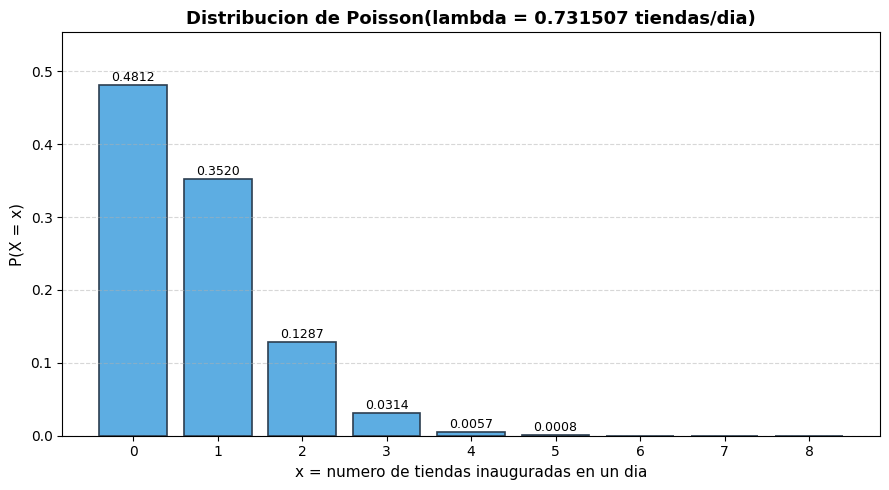

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x_vals, probs, color="#5dade2", edgecolor="#2c3e50", linewidth=1.2)

for b, p in zip(bars, probs):
    if p > 0.0005:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{p:.4f}", ha="center", fontsize=9)

ax.set_title("Distribucion de Poisson(lambda = 0.731507 tiendas/dia)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("x = numero de tiendas inauguradas en un dia", fontsize=11)
ax.set_ylabel("P(X = x)", fontsize=11)
ax.set_xticks(x_vals)
ax.set_ylim(0, max(probs)*1.15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Análisis del sesgo

Como $\lambda = 0.731507 < 1$, el coeficiente de asimetría es:

$$\gamma_1 = \frac{1}{\sqrt{\lambda}} = \frac{1}{\sqrt{0.731507}} \approx 1.1692 > 0$$

**Sesgo positivo (asimétrica hacia la derecha); moda en $x = 0$.**

## b) Probabilidad de 2 tiendas en un día

**Fórmula:**
$$P(X_d = 2) = \frac{e^{-\lambda}\,\lambda^2}{2!}$$

**Sustitución con $\lambda = 0.731507$:**
$$P(X_d = 2) = \frac{e^{-0.731507}\,(0.731507)^2}{2!} = \frac{(0.481183)(0.535102)}{2} = 0.128741$$

In [5]:
p_dos = poisson.pmf(2, lam)
print(f"P(X = 2 por dia) = {p_dos:.6f}  =  {p_dos*100:.4f}%")

P(X = 2 por dia) = 0.128741  =  12.8741%


## c) Probabilidad de 6 tiendas en una semana

**Media semanal:** $\lambda_s = 7 \cdot 0.731507 = 5.120548$

**Fórmula:**
$$P(X_s = 6) = \frac{e^{-\lambda_s}\,\lambda_s^6}{6!}$$

**Sustitución:**
$$P(X_s = 6) = \frac{e^{-5.120548}\,(5.120548)^6}{720} = \frac{(0.005973)(18025.9691)}{720} = 0.149534$$

In [6]:
p_seis = poisson.pmf(6, lam_sem)
print(f"P(X = 6 por semana) = {p_seis:.6f}  =  {p_seis*100:.4f}%")

P(X = 6 por semana) = 0.149534  =  14.9534%


## d) Discusión económica

**Beneficios de la inversión trasnacional (W):**

- Generación de empleo formal y capacitación.
- Derrama económica y pago de impuestos locales.
- Economías de escala → precios competitivos.
- Inclusión financiera y acceso a tecnología de pago.

**Comparativa supermercados vs. mercados tradicionales:**

| Criterio       | Supermercados (W)            | Mercados tradicionales      |
|----------------|------------------------------|------------------------------|
| Precio         | Competitivos (volumen)       | Más altos, sin escala        |
| Variedad       | Muy amplia                   | Limitada al proveedor        |
| Empleo         | Formal con prestaciones      | Informal, familiar           |
| Identidad      | Estandarizado                | Cultura regional             |
| Impacto social | Inversión extranjera         | Dinero se queda en la zona   |

---

## Resumen de resultados

| Inciso | Resultado |
|--------|-----------|
| a) lambda diario | 0.731507 |
| a) lambda semanal | 5.120548 |
| Sesgo | Positivo (cola a la derecha), moda en x = 0 |
| b) P(2 en un día) | **0.128741 = 12.8741%** |
| c) P(6 en una semana) | **0.149534 = 14.9534%** |